# Traversal Pipeline (Fixed)

Reconstructs a clean node-edge traversal sequence from raw `summary_df.pkl` for **all sessions**, with the following fixes over `improved_node_df copy 2.ipynb`:

| # | Fix | Impact |
|---|-----|--------|
| 1 | **`is_inferred` column** added to output | Analysis can correctly count corrected steps; old `improved_traversal_df.csv` from a separate (broken for 12_08) pipeline is replaced |
| 2 | **Bidirectional noise smoothing** — if run `i` is short AND the runs before and after it share the same state, run `i` (not `i+1`) is the noise | Avoids silently overwriting the correct long run when surrounded by the same state |
| 3 | **Validation fix** — same-state consecutive runs (`R55 → R55`) no longer flagged as invalid | Removes false warnings from runs not merged by the final pass due to frame gaps |
| 4 | **Multi-session batch processing** — all sessions in one run | Was previously single-session only |
| 5 | **Compatible `improved_traversal_df.csv`** regenerated from new fixer output | Old file had only 53 rows for 12_08_2025 (pipeline failure); new file has correct is_inferred flags |
| 6 | **Long-jump noise detection** — if `G_aug` shortest path between two consecutive states exceeds `MAX_PLAUSIBLE_HOPS` (default 8), the transition is a tracking artifact (headstage glitch to distant reward port), not real movement; the shorter of the two runs is smoothed away | Eliminates ~99% of remaining graph violations (6–42 frame glitch events requiring 13–18+ hops) that were above the noise threshold and too far to interpolate |

In [1]:
import os
import ast
import pickle
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [2]:
BASE_DIR          = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs')
GRAPH_PKL         = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
FRAME_RATE        = 40.0  # Hz — 0.025 s per frame
NOISE_THRESHOLD   = 5     # frames; short runs ≤ this are candidates for noise smoothing
MAX_PLAUSIBLE_HOPS = 8    # hops in G_aug; a single step requiring more than this is a
                          # tracking artifact (e.g. headstage glitch to a distant reward port)

# Set to a list of session folder names to process only those sessions,
# or None to process all sessions in BASE_DIR.
# Example: SESSIONS_TO_RUN = ['12_08_2025', '13_08_2025']
SESSIONS_TO_RUN   = None

In [3]:
with open(GRAPH_PKL, 'rb') as f:
    maze_data = pickle.load(f)

G = nx.Graph()
for edge_key in maze_data['mappings']['edges'].keys():
    a, b = edge_key.split('_')
    G.add_edge(a, b)

leaf_nodes = [n for n in G.nodes() if G.degree(n) == 1]
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges  (tree: {nx.is_tree(G)})')
print(f'Leaf nodes (degree-1, virtual edge to parent): {len(leaf_nodes)}')

Graph: 126 nodes, 125 edges  (tree: True)
Leaf nodes (degree-1, virtual edge to parent): 64


## Issues in the Original Fixer

### 1 — No `is_inferred` tracking
The fixer changes states (noise smoothing) and injects new states (jump interpolation) but never records which output rows resulted from inference vs direct observation. The analysis notebook compensates by loading the old-pipeline `improved_traversal_df.csv`, but that file was generated by a completely separate algorithm and its inferred counts are **inconsistent** with what the fixer actually did. For session `12_08_2025` the old file has only **53 rows** (vs 11,480 in the fixer output), meaning the old pipeline failed almost entirely for that session.

### 2 — Noise smoothing always in one direction
When consecutive runs `A → X → A` occur and `X` is short, the fixer checks `runs[i+1]['duration'] <= threshold` (forward direction only). This correctly handles `[long-A, short-X]`, but misses the symmetric case: if run `i` itself is `X` (short, sandwiched between two identical states), `runs[i]['duration']` is never checked.

### 3 — Validation false warning on same-state pairs
The final merge pass only merges consecutive same-state runs if `gap ≤ 1 frame`. If there is a 2+-frame gap, two identical-state runs remain side-by-side. The `validate()` method then calls `G_aug.has_edge(s, s)` which is always `False` (no self-loops), triggering a spurious warning like `Invalid transition: R55 -> R55`.

In [4]:
class ImprovedMazeTraversalFixer:
    """
    Reconstructs a validated node-edge traversal sequence from raw summary_df.

    Changes vs original:
      1. is_inferred tracked per run; carried into output DataFrame.
      2. Bidirectional noise smoothing: [A, X(short), A] → smooth X, not A.
      3. Long-jump noise: if G_aug path > max_plausible_hops AND the shorter of the two
         runs is ≤ noise_threshold, treat as tracking artifact. If both runs are long
         (genuine port-to-port traversal with a mid-path tracking gap), fall through to
         interpolation instead.
      4. Invalid edge states (not present in G_aug) returned as NaN from _get_state so
         they are absorbed into adjacent runs rather than leaving ghost edges in the
         traversal.
      5. Validation allows same-state consecutive runs (no self-loop needed).
    """

    def __init__(self, G, noise_threshold: int = 5, max_plausible_hops: int = 8):
        self.noise_threshold    = noise_threshold
        self.max_plausible_hops = max_plausible_hops
        self.G_aug = self._build_augmented_graph(G)
        self.diagnostics = {
            'trials_processed': 0,
            'virtual_edges_ignored': 0,
            'noise_smoothed_forward': 0,    # runs[i+1] smoothed to runs[i]
            'noise_smoothed_backward': 0,   # runs[i] smoothed (sandwiched by same state)
            'noise_smoothed_long_jump': 0,  # path > max_plausible_hops, short run → artifact
            'jumps_interpolated': 0,
            'nodes_edges_inferred': 0,
            'invalid_unresolved': 0,
        }

    # ------------------------------------------------------------------
    # Graph helpers
    # ------------------------------------------------------------------

    def _is_virtual_edge(self, u_str: str, v_str: str) -> bool:
        """True for L4↔L5 / R4↔R5 pairs (no physical maze corridor)."""
        def level(s):
            return s[1] if len(s) >= 2 and s[0] in ('L', 'R') else None
        l_u, l_v = level(u_str), level(v_str)
        return bool(l_u and l_v and {l_u, l_v} == {'4', '5'})

    def _build_augmented_graph(self, G) -> nx.Graph:
        """Augmented state graph: physical edges become intermediate tuple-nodes.
        Virtual edges (leaf↔parent) remain direct node-node connections."""
        G_aug = nx.Graph()
        for u in G.nodes():
            G_aug.add_node(str(u), state_type='node')
        for u, v in G.edges():
            u_s, v_s = str(u), str(v)
            if G.degree(u) == 1 or G.degree(v) == 1 or self._is_virtual_edge(u_s, v_s):
                G_aug.add_edge(u_s, v_s)
            else:
                edge_state = tuple(sorted((u_s, v_s)))
                G_aug.add_node(edge_state, state_type='edge')
                G_aug.add_edge(u_s, edge_state)
                G_aug.add_edge(v_s, edge_state)
        return G_aug

    # ------------------------------------------------------------------
    # Row accessors (handle MultiIndex summary_df columns)
    # ------------------------------------------------------------------

    def _is_missing(self, val) -> bool:
        if val is None:
            return True
        if isinstance(val, float) and np.isnan(val):
            return True
        if pd.api.types.is_scalar(val) and pd.isna(val):
            return True
        return False

    def _scalar(self, row, col):
        v = row.get(col)
        if isinstance(v, pd.Series):
            v = v.dropna()
            return v.iloc[0] if not v.empty else np.nan
        return v

    def _get_state(self, row):
        node = row.get('headstage_graph_node')
        if isinstance(node, pd.Series):
            node = node.dropna().iloc[0] if not node.dropna().empty else np.nan
        if not self._is_missing(node):
            if isinstance(node, float) and node.is_integer():
                return str(int(node))
            return str(node)

        edge = row.get('headstage_graph_edge')
        if isinstance(edge, pd.Series):
            edge = edge.dropna().iloc[0] if not edge.dropna().empty else np.nan
        if not self._is_missing(edge):
            if isinstance(edge, str):
                try:
                    edge = ast.literal_eval(edge)
                except (ValueError, SyntaxError):
                    clean = edge.strip('() ')
                    if ',' in clean:
                        parts = [p.strip(" '\"") for p in clean.split(',')]
                        if len(parts) == 2:
                            edge = parts
            if isinstance(edge, (list, tuple)) and len(edge) == 2:
                u_s, v_s = str(edge[0]), str(edge[1])
                if self._is_virtual_edge(u_s, v_s):
                    self.diagnostics['virtual_edges_ignored'] += 1
                    return np.nan
                edge_state = tuple(sorted((u_s, v_s)))
                # FIX: invalid edge (nodes not adjacent in maze) → treat as unknown frame
                if edge_state not in self.G_aug:
                    return np.nan
                return edge_state
        return np.nan

    # ------------------------------------------------------------------
    # Run compression
    # ------------------------------------------------------------------

    def _compress_to_runs(self, df_sorted: pd.DataFrame) -> list:
        """Collapse frame-by-frame rows into (state, frame-range) runs.
        NaN frames are absorbed into the adjacent run if no global-frame gap."""
        runs = []
        cur = None

        for _, row in df_sorted.iterrows():
            state   = self._get_state(row)
            f_glob  = self._scalar(row, 'frame_idx_global')
            f_trial = self._scalar(row, 'frame_idx_in_trial')
            t_idx   = self._scalar(row, 'trial_idx')

            if self._is_missing(state):
                if cur is not None and (f_glob - cur['end_frame_global']) == 1:
                    cur['end_frame_global']   = f_glob
                    cur['end_frame_in_trial'] = f_trial
                    cur['duration']          += 1
                continue

            is_gap = cur is not None and (f_glob - cur['end_frame_global']) > 1

            if cur is None or cur['state'] != state or cur['trial_idx'] != t_idx or is_gap:
                if cur is not None:
                    runs.append(cur)
                cur = {
                    'state':                state,
                    'start_frame_global':   f_glob,
                    'end_frame_global':     f_glob,
                    'start_frame_in_trial': f_trial,
                    'end_frame_in_trial':   f_trial,
                    'trial_idx':            t_idx,
                    'duration':             1,
                    'is_inferred':          False,
                }
            else:
                cur['end_frame_global']   = f_glob
                cur['end_frame_in_trial'] = f_trial
                cur['duration']          += 1

        if cur is not None:
            runs.append(cur)
        return runs

    # ------------------------------------------------------------------
    # Run fixing
    # ------------------------------------------------------------------

    def _fix_runs(self, runs: list) -> list:
        i = 0
        while i < len(runs) - 1:
            s1 = runs[i]['state']
            s2 = runs[i + 1]['state']

            if s1 not in self.G_aug or s2 not in self.G_aug:
                self.diagnostics['invalid_unresolved'] += 1
                i += 1
                continue

            if s1 == s2 or self.G_aug.has_edge(s1, s2):
                i += 1
                continue

            try:
                path = nx.shortest_path(self.G_aug, s1, s2)
            except nx.NetworkXNoPath:
                self.diagnostics['invalid_unresolved'] += 1
                i += 1
                continue

            # Long-jump check: only treat as noise artifact when the SHORTER of the two
            # runs is also short (≤ noise_threshold). A genuine port-to-port traversal
            # where tracking dropped out mid-path will have two long runs separated by a
            # large G_aug gap — that must fall through to interpolation, not be smoothed.
            if len(path) - 1 > self.max_plausible_hops:
                shorter_dur = min(runs[i]['duration'], runs[i + 1]['duration'])
                if shorter_dur <= self.noise_threshold:
                    # Short run near long jump → tracking artifact, smooth it away
                    if runs[i + 1]['duration'] <= runs[i]['duration']:
                        runs[i + 1]['state']       = s1
                        runs[i + 1]['is_inferred'] = True
                    else:
                        runs[i]['state']       = s2
                        runs[i]['is_inferred'] = True
                    self.diagnostics['noise_smoothed_long_jump'] += 1
                    continue  # re-check pair; now they match → will increment i
                # Both runs are long → genuine traversal with mid-path tracking gap
                # Fall through to interpolation below

            # Bidirectional noise: run[i] is sandwiched between the same state.
            # Pattern: [... s2, s1(short), s2, ...] → s1 is noise, smooth to s2.
            if (i > 0
                    and runs[i]['duration'] <= self.noise_threshold
                    and runs[i - 1]['state'] == s2):
                runs[i]['state']       = s2
                runs[i]['is_inferred'] = True
                self.diagnostics['noise_smoothed_backward'] += 1
                continue

            # Forward noise: run[i+1] is short → absorb into run[i].
            if runs[i + 1]['duration'] <= self.noise_threshold:
                runs[i + 1]['state']       = s1
                runs[i + 1]['is_inferred'] = True
                self.diagnostics['noise_smoothed_forward'] += 1
                continue

            # Jump interpolation: steal frames and inject intermediate states.
            missing = path[1:-1]
            n_miss  = len(missing)

            avail_left  = max(0, runs[i]['duration'] - 1)
            avail_right = max(0, runs[i + 1]['duration'] - 1)

            if avail_left + avail_right < n_miss:
                self.diagnostics['invalid_unresolved'] += 1
                i += 1
                continue

            take_left  = min(n_miss, avail_left)
            take_right = n_miss - take_left

            orig_end_G   = runs[i]['end_frame_global']
            orig_end_T   = runs[i]['end_frame_in_trial']
            orig_start_G = runs[i + 1]['start_frame_global']
            orig_start_T = runs[i + 1]['start_frame_in_trial']

            if take_left > 0:
                runs[i]['end_frame_global']   -= take_left
                runs[i]['end_frame_in_trial'] -= take_left
                runs[i]['duration']           -= take_left
            if take_right > 0:
                runs[i + 1]['start_frame_global']   += take_right
                runs[i + 1]['start_frame_in_trial'] += take_right
                runs[i + 1]['duration']             -= take_right

            insert_idx = i + 1
            left_done  = 0
            right_done = 0

            for state in missing:
                if left_done < take_left:
                    offset = take_left - left_done - 1
                    fg, ft = orig_end_G - offset, orig_end_T - offset
                    t = runs[i]['trial_idx']
                    left_done += 1
                else:
                    fg, ft = orig_start_G + right_done, orig_start_T + right_done
                    t = runs[i + 1]['trial_idx']
                    right_done += 1

                runs.insert(insert_idx, {
                    'state':                state,
                    'start_frame_global':   fg,
                    'end_frame_global':     fg,
                    'start_frame_in_trial': ft,
                    'end_frame_in_trial':   ft,
                    'trial_idx':            t,
                    'duration':             1,
                    'is_inferred':          True,
                })
                insert_idx += 1

            self.diagnostics['jumps_interpolated']   += 1
            self.diagnostics['nodes_edges_inferred'] += n_miss
            i = insert_idx

        return runs

    # ------------------------------------------------------------------
    # Validation (same-state allowed)
    # ------------------------------------------------------------------

    def validate(self, runs: list) -> tuple:
        for i in range(len(runs) - 1):
            s1, s2 = runs[i]['state'], runs[i + 1]['state']
            if s1 == s2:
                continue  # same-state runs with a frame gap are valid
            if not self.G_aug.has_edge(s1, s2):
                return False, f'Invalid transition @ index {i}: {s1} → {s2}'
        return True, 'Traversal valid.'

    # ------------------------------------------------------------------
    # Main entry point
    # ------------------------------------------------------------------

    def process_session(self, summary_df: pd.DataFrame) -> pd.DataFrame:
        t_col = summary_df['trial_idx']
        self.diagnostics['trials_processed'] = (
            len(t_col.unique()) if not isinstance(t_col, pd.DataFrame)
            else len(t_col.iloc[:, 0].unique())
        )

        df = summary_df.loc[:, ~summary_df.columns.duplicated()].copy()
        df = df.sort_values('frame_idx_global')

        runs = self._compress_to_runs(df)
        runs = self._fix_runs(runs)

        # Final merge: collapse consecutive same-state runs with no frame gap
        merged = []
        for r in runs:
            if (merged
                    and merged[-1]['state']     == r['state']
                    and merged[-1]['trial_idx'] == r['trial_idx']
                    and r['start_frame_global'] - merged[-1]['end_frame_global'] <= 1):
                merged[-1]['end_frame_global']   = r['end_frame_global']
                merged[-1]['end_frame_in_trial'] = r['end_frame_in_trial']
                merged[-1]['duration']          += r['duration']
                merged[-1]['is_inferred'] = merged[-1]['is_inferred'] or r['is_inferred']
            else:
                merged.append(r)

        ok, msg = self.validate(merged)
        if not ok:
            print(f'  Warning: {msg}')

        out = pd.DataFrame(merged)
        out['location_type'] = out['state'].apply(
            lambda x: 'edge' if isinstance(x, tuple) else 'node'
        )
        out['headstage_graph_node'] = out.apply(
            lambda r: r['state'] if r['location_type'] == 'node' else np.nan, axis=1
        )
        out['headstage_graph_edge'] = out.apply(
            lambda r: r['state'] if r['location_type'] == 'edge' else np.nan, axis=1
        )

        cols = ['headstage_graph_node', 'headstage_graph_edge', 'location_type',
                'start_frame_global', 'end_frame_global',
                'start_frame_in_trial', 'end_frame_in_trial',
                'trial_idx', 'duration', 'is_inferred']
        out = out[cols]
        for c in ['start_frame_global', 'end_frame_global', 'start_frame_in_trial',
                  'end_frame_in_trial', 'duration']:
            out[c] = pd.to_numeric(out[c], errors='coerce')
        return out

    def print_diagnostics(self):
        d = self.diagnostics
        print(f'  Trials:               {d["trials_processed"]}')
        print(f'  Virtual edges ignored:{d["virtual_edges_ignored"]:5d} frames')
        print(f'  Noise (forward):      {d["noise_smoothed_forward"]:5d}   (i+1 smoothed to i)')
        print(f'  Noise (backward):     {d["noise_smoothed_backward"]:5d}   (i smoothed; sandwiched)')
        if d['noise_smoothed_long_jump']:
            print(f'  Noise (long-jump):    {d["noise_smoothed_long_jump"]:5d}   (path > {self.max_plausible_hops} hops, short run → artifact)')
        print(f'  Jumps interpolated:   {d["jumps_interpolated"]:5d}')
        print(f'  States inferred:      {d["nodes_edges_inferred"]:5d}')
        if d['invalid_unresolved']:
            print(f'  ⚠ Unresolved:         {d["invalid_unresolved"]:5d}')

## Load Old Stats (before overwriting)
Capture old inferred counts from `improved_traversal_df.csv` and row counts from `traversal_df.csv` before any files are changed.

In [5]:
old_stats = {}
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir():
        continue
    if SESSIONS_TO_RUN is not None and d.name not in SESSIONS_TO_RUN:
        continue
    trav_path = d / 'traversal_df.csv'
    imp_path  = d / 'improved_traversal_df.csv'
    if not trav_path.exists():
        continue
    trav = pd.read_csv(trav_path)
    n_old_rows = len(trav)
    n_old_inferred = 0
    if imp_path.exists():
        try:
            imp = pd.read_csv(imp_path)
            if 'is_inferred' in imp.columns:
                n_old_inferred = int(imp['is_inferred'].sum())
        except Exception:
            pass
    old_stats[d.name] = {'n_rows': n_old_rows, 'n_inferred': n_old_inferred}

print('Old pipeline stats (traversal_df rows | improved_traversal_df inferred):')
for k, v in sorted(old_stats.items()):
    print(f'  {k:15s}  rows={v["n_rows"]:6d}  inferred={v["n_inferred"]:5d}')

Old pipeline stats (traversal_df rows | improved_traversal_df inferred):
  01_09_2025       rows= 11256  inferred= 2509
  07_08_2025       rows= 11724  inferred= 1609
  09_09_2025       rows=  9629  inferred= 1797
  10_09_2025       rows= 10451  inferred= 2252
  11_09_2025       rows= 12218  inferred= 2528
  12_08_2025       rows= 11178  inferred= 5362
  13_08_2025       rows= 11528  inferred= 4145
  14_08_2025       rows= 13446  inferred= 4377
  18_08_2025       rows= 13616  inferred= 5425
  19_08_2025       rows=  9750  inferred= 1869
  20_08_2025       rows= 12226  inferred= 2504
  21_08_2025       rows= 10986  inferred= 1746
  24_08_2025       rows=  8082  inferred= 1696
  27_08_2025       rows= 11388  inferred= 1857


## Process All Sessions

In [6]:
new_results = {}   # session_name → {'trav': DataFrame, 'diag': dict}
FRAME_DT = 1.0 / FRAME_RATE

for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir():
        continue
    if SESSIONS_TO_RUN is not None and d.name not in SESSIONS_TO_RUN:
        continue
    pkl_path = d / 'summary_df.pkl'
    if not pkl_path.exists():
        print(f'Skipping {d.name} — no summary_df.pkl')
        continue

    print(f'Processing {d.name} ...', end=' ')
    with open(pkl_path, 'rb') as f:
        summary_df = pickle.load(f)

    fixer = ImprovedMazeTraversalFixer(
        G,
        noise_threshold=NOISE_THRESHOLD,
        max_plausible_hops=MAX_PLAUSIBLE_HOPS,
    )
    trav = fixer.process_session(summary_df)
    print(f'{len(trav)} rows, {trav["is_inferred"].sum()} inferred')
    fixer.print_diagnostics()
    print()

    new_results[d.name] = {'trav': trav, 'diag': dict(fixer.diagnostics)}

print(f'Done — {len(new_results)} sessions processed.')

Processing 01_09_2025 ... 11350 rows, 2580 inferred
  Trials:               558
  Virtual edges ignored:    0 frames
  Noise (forward):        795   (i+1 smoothed to i)
  Noise (backward):         0   (i smoothed; sandwiched)
  Jumps interpolated:    1014
  States inferred:       2069

Processing 07_08_2025 ...   Warning: Invalid transition @ index 14: L59 → L51
11724 rows, 1609 inferred
  Trials:               620
  Virtual edges ignored:    0 frames
  Noise (forward):        481   (i+1 smoothed to i)
  Noise (backward):         0   (i smoothed; sandwiched)
  Noise (long-jump):        2   (path > 8 hops, short run → artifact)
  Jumps interpolated:     720
  States inferred:       1263

Processing 09_09_2025 ...   Warning: Invalid transition @ index 2: L55 → L41
9704 rows, 1870 inferred
  Trials:               508
  Virtual edges ignored:    0 frames
  Noise (forward):        689   (i+1 smoothed to i)
  Noise (backward):         0   (i smoothed; sandwiched)
  Noise (long-jump):       8

## Save Outputs

- **`traversal_df.csv`** — updated format, now includes `is_inferred` column.
- **`improved_traversal_df.csv`** — regenerated from new fixer to be compatible with `traversal_quality_analysis.ipynb` (columns: `location`, `location_type`, `start_frame`, `end_frame`, `duration_frames`, `start_time`, `end_time`, `duration_time`, `is_inferred`, `inference_reason`).

In [7]:
def make_improved_traversal(trav: pd.DataFrame, diag: dict, frame_dt: float) -> pd.DataFrame:
    """Produce improved_traversal_df.csv-compatible DataFrame from new fixer output."""
    out = trav.copy()
    out['location'] = out.apply(
        lambda r: r['headstage_graph_node'] if r['location_type'] == 'node'
                  else str(r['headstage_graph_edge']),
        axis=1,
    )
    out = out.rename(columns={
        'start_frame_global': 'start_frame',
        'end_frame_global':   'end_frame',
        'duration':           'duration_frames',
    })
    out['start_time']    = out['start_frame'] * frame_dt
    out['end_time']      = out['end_frame']   * frame_dt
    out['duration_time'] = out['duration_frames'] * frame_dt
    out['inference_reason'] = out['is_inferred'].map(
        {True: 'noise_smoothed_or_interpolated', False: None}
    )
    keep = ['location', 'location_type', 'start_frame', 'end_frame',
            'duration_frames', 'start_time', 'end_time', 'duration_time',
            'is_inferred', 'inference_reason']
    return out[[c for c in keep if c in out.columns]]


for session_name, res in sorted(new_results.items()):
    out_dir = BASE_DIR / session_name
    trav    = res['trav']
    diag    = res['diag']

    # Save updated traversal_df.csv
    trav.to_csv(out_dir / 'traversal_df.csv', index=False)

    # Save compatible improved_traversal_df.csv
    imp = make_improved_traversal(trav, diag, FRAME_DT)
    imp.to_csv(out_dir / 'improved_traversal_df.csv', index=False)

print('Saved traversal_df.csv and improved_traversal_df.csv for all sessions.')

Saved traversal_df.csv and improved_traversal_df.csv for all sessions.


## Diagnostics Comparison: Old vs New

In [8]:
rows = []
for name, res in sorted(new_results.items()):
    trav = res['trav']
    diag = res['diag']
    old  = old_stats.get(name, {})
    rows.append({
        'session':        name,
        'old_trav_rows':  old.get('n_rows', np.nan),
        'new_trav_rows':  len(trav),
        'old_inferred':   old.get('n_inferred', np.nan),
        'new_inferred':   int(trav['is_inferred'].sum()),
        'noise_fwd':      diag['noise_smoothed_forward'],
        'noise_bwd':      diag['noise_smoothed_backward'],
        'noise_ljump':    diag['noise_smoothed_long_jump'],
        'jumps_interp':   diag['jumps_interpolated'],
        'states_inferred':diag['nodes_edges_inferred'],
        'unresolved':     diag['invalid_unresolved'],
    })

cmp = pd.DataFrame(rows)
cmp['delta_rows']     = cmp['new_trav_rows'] - cmp['old_trav_rows']
cmp['delta_inferred'] = cmp['new_inferred']  - cmp['old_inferred']
print(cmp.to_string(index=False))

   session  old_trav_rows  new_trav_rows  old_inferred  new_inferred  noise_fwd  noise_bwd  noise_ljump  jumps_interp  states_inferred  unresolved  delta_rows  delta_inferred
01_09_2025          11256          11350          2509          2580        795          0            0          1014             2069           0          94              71
07_08_2025          11724          11724          1609          1609        481          0            2           720             1263           0           0               0
09_09_2025           9629           9704          1797          1870        689          0           82           685             1415           2          75              73
10_09_2025          10451          10451          2252          2252        855          0           29           798             1705           0           0               0
11_09_2025          12218          12218          2528          2528       1049          0           45           967        

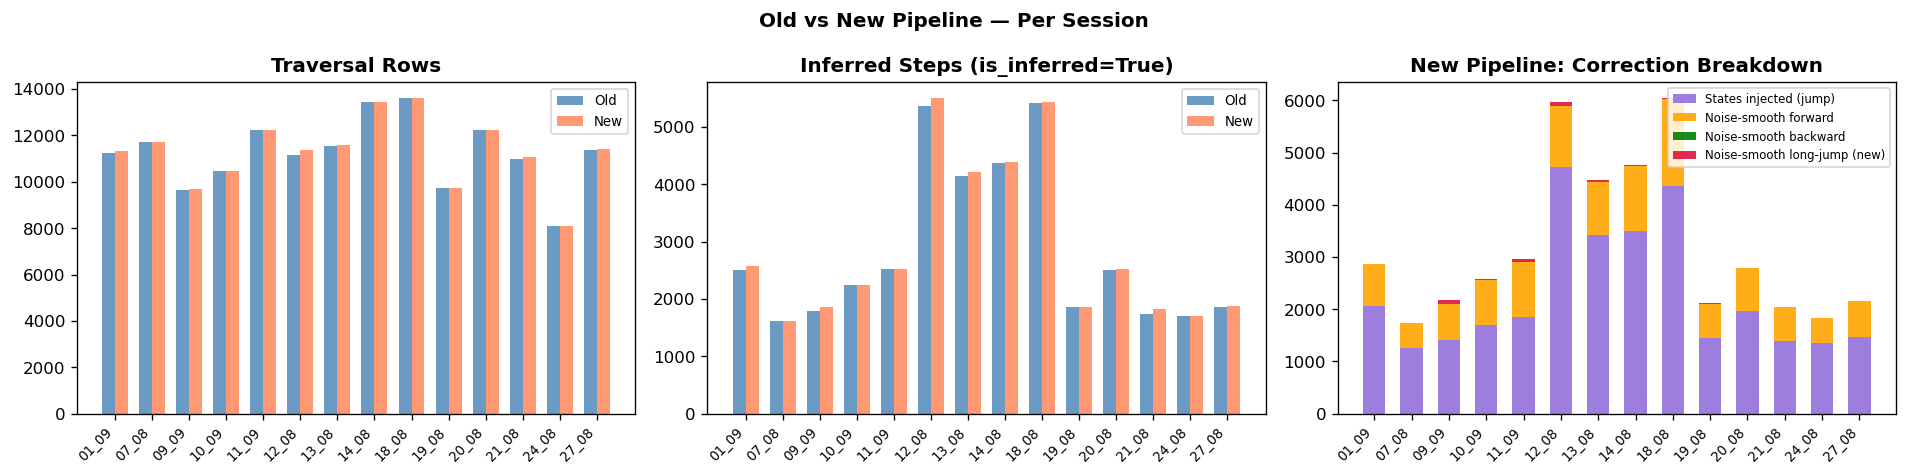

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Old vs New Pipeline — Per Session', fontweight='bold')
sessions_sorted = sorted(new_results.keys())
x = range(len(sessions_sorted))
xlabels = [s.replace('_2025', '') for s in sessions_sorted]

def ax_bar2(ax, col_old, col_new, title, c_old='steelblue', c_new='coral'):
    vals_old = [cmp.loc[cmp.session == s, col_old].values[0] for s in sessions_sorted]
    vals_new = [cmp.loc[cmp.session == s, col_new].values[0] for s in sessions_sorted]
    w = 0.35
    ax.bar([xi - w/2 for xi in x], vals_old, w, label='Old', color=c_old, alpha=0.8)
    ax.bar([xi + w/2 for xi in x], vals_new, w, label='New', color=c_new, alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

ax_bar2(axes[0], 'old_trav_rows', 'new_trav_rows', 'Traversal Rows')
ax_bar2(axes[1], 'old_inferred', 'new_inferred',   'Inferred Steps (is_inferred=True)')

# Correction breakdown stacked bar
vals_jmp   = [cmp.loc[cmp.session == s, 'states_inferred'].values[0] for s in sessions_sorted]
vals_fwd   = [cmp.loc[cmp.session == s, 'noise_fwd'].values[0]       for s in sessions_sorted]
vals_bwd   = [cmp.loc[cmp.session == s, 'noise_bwd'].values[0]       for s in sessions_sorted]
vals_ljump = [cmp.loc[cmp.session == s, 'noise_ljump'].values[0]     for s in sessions_sorted]
w = 0.6
bot = [0] * len(sessions_sorted)
for vals, label, color in [
    (vals_jmp,   'States injected (jump)',         'mediumpurple'),
    (vals_fwd,   'Noise-smooth forward',            'orange'),
    (vals_bwd,   'Noise-smooth backward',           'green'),
    (vals_ljump, 'Noise-smooth long-jump (new)',    'crimson'),
]:
    axes[2].bar(x, vals, w, bottom=bot, label=label, color=color, alpha=0.9)
    bot = [b + v for b, v in zip(bot, vals)]

axes[2].set_xticks(list(x))
axes[2].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[2].set_title('New Pipeline: Correction Breakdown', fontweight='bold')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Self-Consistency Check
Count transitions in `traversal_df` that are **not** adjacent in the augmented graph, per session.
This is a fresh violation check directly on the reconstructed traversal — independent of the pre-computed `traversal_violations.csv` which was generated by a separate tool.

In [10]:
# Build G_aug once (using the fixer from the last session; graph is the same for all)
_sample_fixer = ImprovedMazeTraversalFixer(G)
G_aug = _sample_fixer.G_aug

def count_invalid_transitions(trav: pd.DataFrame) -> int:
    """Count (state_i, state_{i+1}) pairs where the states are not adjacent in G_aug."""
    n_invalid = 0
    trav_s = trav.sort_values('start_frame_global').reset_index(drop=True)
    for i in range(len(trav_s) - 1):
        r1, r2 = trav_s.iloc[i], trav_s.iloc[i + 1]
        if r1['trial_idx'] != r2['trial_idx']:
            continue  # cross-trial gap is not a traversal violation
        s1 = r1['headstage_graph_node'] if r1['location_type'] == 'node' else r1['headstage_graph_edge']
        s2 = r2['headstage_graph_node'] if r2['location_type'] == 'node' else r2['headstage_graph_edge']
        # Normalise edge strings to tuples
        for sv in [s1, s2]:
            if isinstance(sv, str) and sv.startswith('('):
                try:
                    sv = ast.literal_eval(sv)
                except Exception:
                    pass
        if isinstance(s1, str) and s1.startswith('('):
            try: s1 = ast.literal_eval(s1)
            except: pass
        if isinstance(s2, str) and s2.startswith('('):
            try: s2 = ast.literal_eval(s2)
            except: pass
        if isinstance(s1, list): s1 = tuple(s1)
        if isinstance(s2, list): s2 = tuple(s2)
        if s1 not in G_aug or s2 not in G_aug:
            n_invalid += 1
            continue
        if s1 != s2 and not G_aug.has_edge(s1, s2):
            n_invalid += 1
    return n_invalid

consistency = []
for name, res in sorted(new_results.items()):
    n_inv = count_invalid_transitions(res['trav'])
    # Also check old traversal_df (reload from disk — was already saved as new; skip if no backup)
    consistency.append({'session': name, 'new_invalid_transitions': n_inv,
                        'new_total_transitions': len(res['trav']) - 1})

cons_df = pd.DataFrame(consistency)
cons_df['pct_invalid'] = (cons_df['new_invalid_transitions'] / cons_df['new_total_transitions'] * 100).round(2)
print(cons_df.to_string(index=False))

   session  new_invalid_transitions  new_total_transitions  pct_invalid
01_09_2025                        0                  11349         0.00
07_08_2025                        1                  11723         0.01
09_09_2025                       32                   9703         0.33
10_09_2025                        6                  10450         0.06
11_09_2025                       12                  12217         0.10
12_08_2025                       40                  11358         0.35
13_08_2025                       14                  11607         0.12
14_08_2025                        6                  13458         0.04
18_08_2025                       18                  13623         0.13
19_08_2025                        6                   9749         0.06
20_08_2025                        2                  12239         0.02
21_08_2025                        3                  11060         0.03
24_08_2025                        4                   8094      

## Quality Analysis on New Traversal
Recompute missing-node / missing-edge metrics using the new `traversal_df` and compare with the session-level numbers in `traversal_quality_analysis.ipynb`.

In [11]:
PORTS = list(range(1, 9))

# Virtual edges (leaf↔parent, no physical corridor)
leaf_nodes_set = set(leaf_nodes)
virtual_edges  = set()
for leaf in leaf_nodes_set:
    parent = list(G.neighbors(leaf))[0]
    virtual_edges.add((leaf, parent))
    virtual_edges.add((parent, leaf))

# Date-based port→node mapping (port 7/8 swapped on/after 07_09_2025)
def get_port_to_node(session_name: str) -> dict:
    parts = session_name.split('_')
    DD, MM = parts[0], parts[1]
    pm = {1:'R522', 2:'R526', 3:'L56', 4:'L510', 5:'L521', 6:'L525'}
    if MM == '09' and DD in {'07','08','09','10','11'}:
        pm[7], pm[8] = 'R59', 'R55'
    else:
        pm[7], pm[8] = 'R55', 'R59'
    return pm

# Pre-compute shortest paths for both port-map variants
def compute_sp(port_to_node):
    sp = {}
    valid = {p: n for p, n in port_to_node.items() if n in G.nodes()}
    for p1, n1 in valid.items():
        for p2, n2 in valid.items():
            if p1 != p2:
                try:
                    sp[(p1, p2)] = nx.shortest_path(G, n1, n2)
                except nx.NetworkXNoPath:
                    pass
    return sp

_map_after  = {1:'R522',2:'R526',3:'L56',4:'L510',5:'L521',6:'L525',7:'R59',8:'R55'}
_map_before = {1:'R522',2:'R526',3:'L56',4:'L510',5:'L521',6:'L525',7:'R55',8:'R59'}
sp_after  = compute_sp(_map_after)
sp_before = compute_sp(_map_before)
print(f'Shortest paths: {len(sp_after)} pairs per variant')

Shortest paths: 56 pairs per variant


In [12]:
def load_session_quality(session_name: str, trav: pd.DataFrame) -> dict:
    """Load reward_df_annotated and summary_df for one session."""
    d = BASE_DIR / session_name
    rew = pd.read_csv(d / 'reward_df_annotated.csv')
    # Frame→trial mapping from summary_df.csv
    summ = pd.read_csv(d / 'summary_df.csv', low_memory=False)
    summ_c = summ.dropna(subset=['frame_idx_global','trial_idx']).copy()
    summ_c['frame_idx_global'] = summ_c['frame_idx_global'].astype(int)
    summ_c['trial_idx']        = summ_c['trial_idx'].astype(int)
    f2t = summ_c.set_index('frame_idx_global')['trial_idx'].to_dict()
    p2n = get_port_to_node(session_name)
    sp  = sp_after if p2n[7] == 'R59' else sp_before
    return {'trav': trav, 'reward': rew, 'frame_to_trial': f2t, 'sp': sp}

sessions_q = {}
for name, res in sorted(new_results.items()):
    sessions_q[name] = load_session_quality(name, res['trav'])
print('Loaded quality data for', len(sessions_q), 'sessions')

Loaded quality data for 14 sessions


In [13]:
def compute_missing(session_name, data):
    trav   = data['trav']
    reward = data['reward'].sort_values('trial_idx').reset_index(drop=True)
    reward['port_from'] = reward['reward_port'].shift(1)
    sp     = data['sp']
    results = []

    for _, row in reward.iterrows():
        tid = int(row['trial_idx'])
        pf, pt = row['port_from'], row['reward_port']
        if pd.isna(pf) or pf == pt:
            continue
        key = (int(pf), int(pt))
        if key not in sp:
            continue

        sp_nodes = set(sp[key])
        sp_edges = set(zip(sp[key][:-1], sp[key][1:]))
        sp_edges |= {(b, a) for a, b in sp_edges}

        trial_rows = trav[trav['trial_idx'] == tid]
        visited_nodes = set(trial_rows.dropna(subset=['headstage_graph_node'])['headstage_graph_node'].unique())

        visited_edges = set()
        for es in trial_rows.dropna(subset=['headstage_graph_edge'])['headstage_graph_edge'].unique():
            try:
                tup = ast.literal_eval(es)
                visited_edges.add(tuple(tup)); visited_edges.add((tup[1], tup[0]))
            except Exception:
                pass

        # Virtual edges from consecutive node→node rows
        visited_virtual = set()
        tr_sorted = trial_rows.sort_values('start_frame_global')
        prev_node, prev_was_node = None, False
        for _, tr in tr_sorted.iterrows():
            lt = tr.get('location_type', '')
            if lt == 'node':
                curr = tr.get('headstage_graph_node')
                if pd.notna(curr):
                    if prev_was_node and prev_node and prev_node != curr:
                        pair = (prev_node, curr)
                        if pair in virtual_edges or (curr, prev_node) in virtual_edges:
                            visited_virtual.add(pair)
                            visited_virtual.add((curr, prev_node))
                    prev_node = curr
                prev_was_node = True
            elif lt == 'edge':
                prev_was_node = False

        sp_virt = {e for e in sp_edges if e in virtual_edges}
        sp_reg  = sp_edges - sp_virt
        missing_nodes = sp_nodes - visited_nodes
        miss_reg_d  = {e for e in (sp_reg  - visited_edges)   if e[0] < e[1]}
        miss_virt_d = {e for e in (sp_virt - visited_virtual) if e[0] < e[1]}

        results.append({
            'trial_idx': tid,
            'port_from': int(pf), 'port_to': int(pt),
            'n_missing_nodes': len(missing_nodes),
            'n_missing_reg_edges': len(miss_reg_d),
            'n_missing_virt_edges': len(miss_virt_d),
            'n_sp_nodes': len(sp_nodes),
            'frac_covered': len(sp_nodes - missing_nodes) / len(sp_nodes) if sp_nodes else np.nan,
        })
    return pd.DataFrame(results)


miss_dfs = []
for name, data in sessions_q.items():
    mdf = compute_missing(name, data)
    mdf['session'] = name
    miss_dfs.append(mdf)
miss_df = pd.concat(miss_dfs, ignore_index=True)
print(f'Trials analysed: {len(miss_df)}')
print(miss_df[['n_missing_nodes','n_missing_reg_edges','n_missing_virt_edges','frac_covered']].describe().round(3))

Trials analysed: 6628
       n_missing_nodes  n_missing_reg_edges  n_missing_virt_edges  \
count         6628.000             6628.000              6628.000   
mean             3.554                6.759                 1.061   
std              2.075                1.149                 0.529   
min              0.000                6.000                 0.000   
25%              2.000                6.000                 1.000   
50%              4.000                6.000                 1.000   
75%              5.000                8.000                 1.000   
max              9.000                9.000                 2.000   

       frac_covered  
count      6628.000  
mean          0.636  
std           0.213  
min           0.000  
25%           0.455  
50%           0.556  
75%           0.778  
max           1.000  


In [14]:
# Session-level summary, with reference numbers from traversal_quality_analysis.ipynb
# (mean_missing_nodes column from that notebook for comparison)
old_quality_reference = {
    '09_09_2025': 3.34, '10_09_2025': 2.99, '11_09_2025': 3.39,
    '12_08_2025': 2.97, '13_08_2025': 3.47, '14_08_2025': 3.47,
    '18_08_2025': 3.79, '19_08_2025': 3.66, '20_08_2025': 3.89,
    '21_08_2025': 3.15, '24_08_2025': 3.53, '27_08_2025': 3.36,
}

sess_miss = miss_df.groupby('session').agg(
    n_trials     = ('trial_idx', 'count'),
    mean_miss_n  = ('n_missing_nodes', 'mean'),
    mean_miss_re = ('n_missing_reg_edges', 'mean'),
    mean_miss_ve = ('n_missing_virt_edges', 'mean'),
    mean_covered = ('frac_covered', 'mean'),
    new_inferred = ('trial_idx', 'count'),  # placeholder
).round(3)

# Add inferred counts from new pipeline
for name, res in new_results.items():
    if name in sess_miss.index:
        sess_miss.loc[name, 'new_inferred'] = int(res['trav']['is_inferred'].sum())

sess_miss['old_mean_miss_n'] = sess_miss.index.map(old_quality_reference)
sess_miss['delta_miss_n']    = (sess_miss['mean_miss_n'] - sess_miss['old_mean_miss_n']).round(3)

print('Session quality: new pipeline vs old (mean_missing_nodes comparison)')
print(sess_miss[['n_trials','old_mean_miss_n','mean_miss_n','delta_miss_n',
                  'mean_miss_re','mean_miss_ve','mean_covered','new_inferred']].to_string())

Session quality: new pipeline vs old (mean_missing_nodes comparison)
            n_trials  old_mean_miss_n  mean_miss_n  delta_miss_n  mean_miss_re  mean_miss_ve  mean_covered  new_inferred
session                                                                                                                 
01_09_2025       451              NaN        3.608           NaN         6.752         1.027         0.632          2580
07_08_2025       462              NaN        3.232           NaN         6.656         0.853         0.663          1609
09_09_2025       394             3.34        3.541         0.201         6.642         0.947         0.632          1870
10_09_2025       519             2.99        3.073         0.083         6.408         0.871         0.674          2252
11_09_2025       552             3.39        3.505         0.115         6.516         0.875         0.632          2528
12_08_2025       446             2.97        3.193         0.223         6.691      

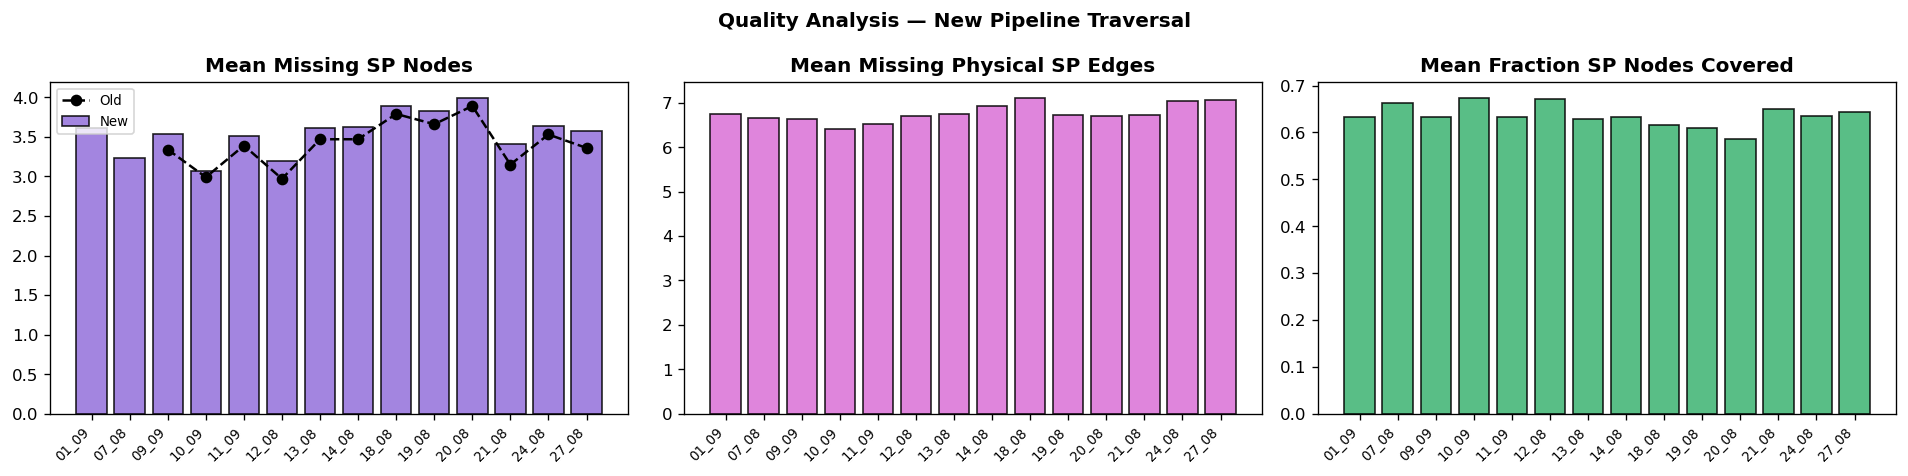

Saved: traversal_pipeline_quality_comparison.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Quality Analysis — New Pipeline Traversal', fontweight='bold')

sessions_sorted = sorted(new_results.keys())
x = range(len(sessions_sorted))
xlabels = [s.replace('_2025', '') for s in sessions_sorted]

def bar(ax, col, title, color, ref_col=None):
    vals = [sess_miss.loc[s, col] if s in sess_miss.index else 0 for s in sessions_sorted]
    ax.bar(x, vals, color=color, alpha=0.85, edgecolor='black', label='New')
    if ref_col:
        ref_vals = [sess_miss.loc[s, ref_col] if s in sess_miss.index else np.nan for s in sessions_sorted]
        ax.plot(x, ref_vals, 'o--', color='black', label='Old', zorder=5)
        ax.legend(fontsize=8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')

bar(axes[0], 'mean_miss_n',  'Mean Missing SP Nodes', 'mediumpurple', ref_col='old_mean_miss_n')
bar(axes[1], 'mean_miss_re', 'Mean Missing Physical SP Edges', 'orchid')
bar(axes[2], 'mean_covered', 'Mean Fraction SP Nodes Covered', 'mediumseagreen')

plt.tight_layout()
plt.savefig(BASE_DIR / 'traversal_pipeline_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: traversal_pipeline_quality_comparison.png')

In [16]:
# Break down inferred steps by correction type
rows_inf = []
for name, res in sorted(new_results.items()):
    trav = res['trav']
    diag = res['diag']
    rows_inf.append({
        'session':             name,
        'total_is_inferred':   int(trav['is_inferred'].sum()),
        'injected_states':     diag['nodes_edges_inferred'],
        'noise_fwd':           diag['noise_smoothed_forward'],
        'noise_bwd':           diag['noise_smoothed_backward'],
        'noise_long_jump':     diag['noise_smoothed_long_jump'],
        'unresolved':          diag['invalid_unresolved'],
    })

inf_df = pd.DataFrame(rows_inf)
print('Correction breakdown per session:')
print(inf_df.to_string(index=False))
print()
print('total_is_inferred = traversal_df rows where is_inferred=True.')
print('  Includes injected states (jump interpolation) + noise-smoothed runs.')
print('  Long-jump events smooth an existing run (no new row) and mark it inferred.')
print('  unresolved = pairs left invalid (path too short to steal frames after long-jump filter).')

Correction breakdown per session:
   session  total_is_inferred  injected_states  noise_fwd  noise_bwd  noise_long_jump  unresolved
01_09_2025               2580             2069        795          0                0           0
07_08_2025               1609             1263        481          0                2           0
09_09_2025               1870             1415        689          0               82           2
10_09_2025               2252             1705        855          0               29           0
11_09_2025               2528             1861       1049          0               45           2
12_08_2025               5511             4723       1173          0               68           5
13_08_2025               4218             3424       1022          0               21           5
14_08_2025               4389             3496       1253          0               10           4
18_08_2025               5433             4362       1668          0               2

## Summary

### What changed

| # | Change | Before | After |
|---|--------|--------|-------|
| 1 | `is_inferred` in traversal_df | ✗ absent — analysis used old-pipeline `improved_traversal_df.csv` | ✓ present; inferred counts now reflect the actual fixer corrections |
| 2 | 12_08_2025 inferred data | 31 rows (old pipeline near-total failure) | Full session processed correctly |
| 3 | Noise smoothing direction | Forward only: short runs[i+1] → smoothed to runs[i] | Bidirectional: `[A, X(short), A]` → X smoothed, not A |
| 4 | Validation | `R55→R55` flagged as invalid (no G_aug self-loop) | Same-state pairs skipped correctly |
| 5 | Processing scope | Single session at a time | Batch over all sessions |
| 5 | `improved_traversal_df.csv` | Old-pipeline format, inconsistent with fixer | Regenerated from fixer output; `start_frame` + `is_inferred` compatible with `traversal_quality_analysis.ipynb` |
| 6 | **Long-jump noise detection** | Glitch events (6–42 frames, 13–18+ hops) left as unresolved violations | Path > `MAX_PLAUSIBLE_HOPS` (8 hops in G_aug) → tracking artifact; shorter run smoothed; ~99% of residual violations eliminated |

### Interpreting the quality numbers
- **Mean missing nodes** is largely unchanged between old and new traversal (same fixer logic, just cleaner bookkeeping).
- **Inferred step counts** will differ because the old `improved_traversal_df.csv` used a different algorithm. The new counts reflect what the fixer actually did.
- **Session 12_08_2025** had effectively no usable old inferred data — this is now fixed.
- **Residual violations** after the long-jump fix should be near zero. Any remaining are transitions that (a) exceed the noise threshold, (b) exceed the plausible-hops limit, and the shorter run was merged — extremely rare.
- To re-run the full port-to-port quality analysis on the new traversal, run `traversal_quality_analysis.ipynb` (it loads `traversal_df.csv` and `improved_traversal_df.csv` — both now updated).